In [10]:
!pip install transformers datasets torchaudio

In [13]:
# ==========================================
# BASELINE SCRIPT (MMS-300M)
# ==========================================

import numpy as np
import torch
from datasets import load_dataset, Audio
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    AutoConfig,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score


print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =========================
# MODEL
# =========================

model_id = "facebook/mms-300m"

feature_extractor = AutoFeatureExtractor.from_pretrained(
    model_id,
    do_normalize=True,
    return_attention_mask=True
)


# =========================
# DATASET
# =========================

dataset = load_dataset("badrex/nnti-dataset-full")

train_ds = dataset["train"].shuffle(seed=42)
valid_ds = dataset["validation"].shuffle(seed=42)

train_ds = train_ds.cast_column("audio_filepath", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio_filepath", Audio(sampling_rate=16000))

LABELS = train_ds.unique("language")

str_to_int = {s: i for i, s in enumerate(LABELS)}
int_to_str = {i: s for s, i in str_to_int.items()}

input_key = "input_values"
max_duration = 7


# =========================
# PREPROCESS
# =========================

def preprocess(batch):

    audio_arrays = [x["array"] for x in batch["audio_filepath"]]

    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=16000,
        truncation=True,
        max_length=int(16000 * max_duration),
        return_attention_mask=True
    )

    inputs["label"] = [str_to_int[x] for x in batch["language"]]

    return inputs


train_ds = train_ds.map(preprocess, remove_columns=train_ds.column_names, batched=True)
valid_ds = valid_ds.map(preprocess, remove_columns=valid_ds.column_names, batched=True)


# =========================
# MODEL CONFIG
# =========================

config = AutoConfig.from_pretrained(model_id)

config.num_labels = len(LABELS)
config.label2id = str_to_int
config.id2label = int_to_str

model = AutoModelForAudioClassification.from_pretrained(model_id, config=config)


# =========================
# DATA COLLATOR
# =========================

class DataCollator:

    def __init__(self, feature_extractor):
        self.fe = feature_extractor

    def __call__(self, features):

        batch = {
            input_key: [f[input_key] for f in features],
            "attention_mask": [f["attention_mask"] for f in features]
        }

        batch = self.fe.pad(batch, return_tensors="pt")

        batch["labels"] = torch.tensor([f["label"] for f in features])

        return batch


data_collator = DataCollator(feature_extractor)


# =========================
# TRAINING
# =========================

training_args = TrainingArguments(

    output_dir="./baseline_results",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    num_train_epochs=3,

    learning_rate=2e-5,

    eval_strategy="steps",   # FIXED
    eval_steps=200,

    logging_steps=50,

    save_strategy="steps",
    save_steps=200,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    fp16=True,

    report_to="none"
)


def compute_metrics(eval_pred):

    preds = np.argmax(eval_pred.predictions, axis=1)

    acc = accuracy_score(eval_pred.label_ids, preds)

    return {"accuracy": acc}


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    processing_class=feature_extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


print("Training baseline...")
trainer.train()

print("Evaluating baseline...")
trainer.evaluate()

GPU available: True
GPU: Tesla T4


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/mms-300m
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training baseline...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating baseline...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 5.600926399230957,
 'eval_accuracy': 0.16454545454545455,
 'eval_runtime': 449.8823,
 'eval_samples_per_second': 7.335,
 'eval_steps_per_second': 0.46,
 'epoch': 3.0}

In [14]:
# ===============================
# GET PREDICTIONS
# ===============================

predictions = trainer.predict(valid_ds)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print("Total validation samples:", len(y_true))

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Total validation samples: 3300


Confusion Matrix

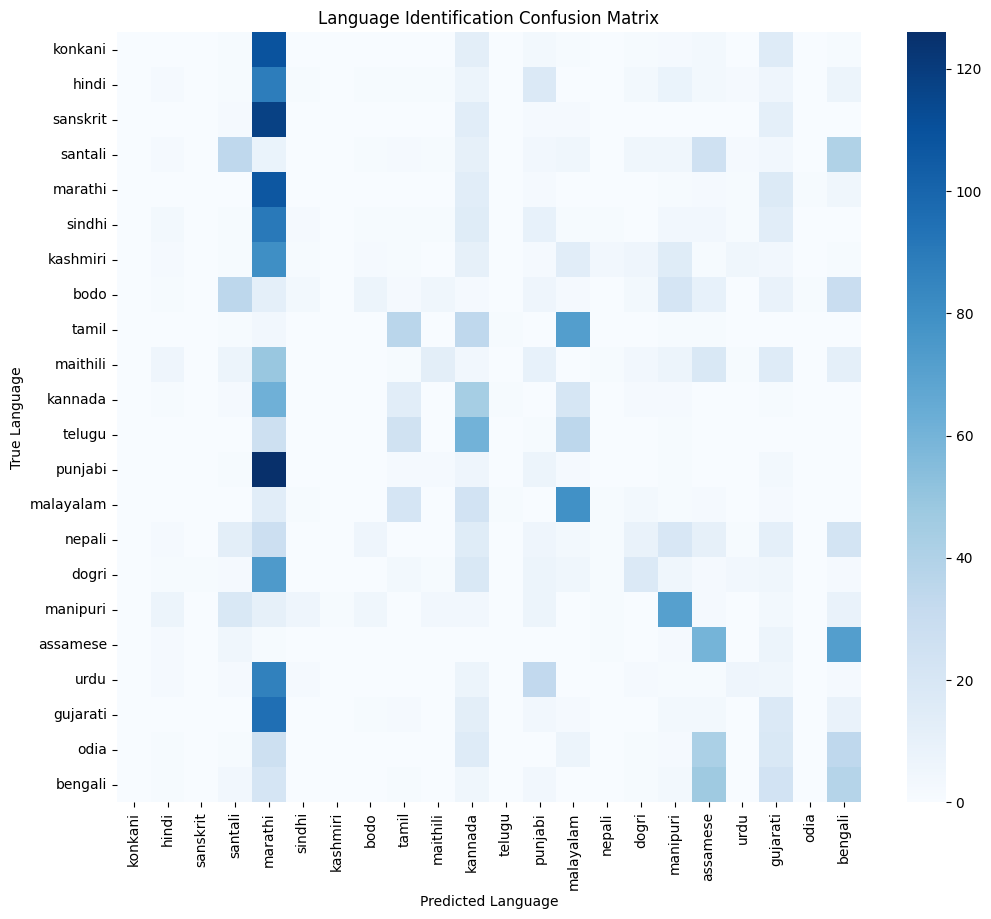

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=int_to_str.values(),
    yticklabels=int_to_str.values()
)

plt.xlabel("Predicted Language")
plt.ylabel("True Language")
plt.title("Language Identification Confusion Matrix")

plt.show()

Class Accuracy per Language

In [16]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=int_to_str.values(),
    output_dict=True
)

df = pd.DataFrame(report).transpose()

print(df)

              precision    recall  f1-score      support
konkani        0.000000  0.000000  0.000000   150.000000
hindi          0.060606  0.013333  0.021858   150.000000
sanskrit       0.000000  0.000000  0.000000   150.000000
santali        0.257576  0.226667  0.241135   150.000000
marathi        0.086221  0.713333  0.153846   150.000000
sindhi         0.125000  0.013333  0.024096   150.000000
kashmiri       0.000000  0.000000  0.000000   150.000000
bodo           0.291667  0.046667  0.080460   150.000000
tamil          0.318584  0.240000  0.273764   150.000000
maithili       0.464286  0.086667  0.146067   150.000000
kannada        0.129794  0.293333  0.179959   150.000000
telugu         0.000000  0.000000  0.000000   150.000000
punjabi        0.055556  0.046667  0.050725   150.000000
malayalam      0.314741  0.526667  0.394015   150.000000
nepali         0.090909  0.006667  0.012422   150.000000
dogri          0.310345  0.120000  0.173077   150.000000
manipuri       0.401130  0.4733

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plot accuracy:

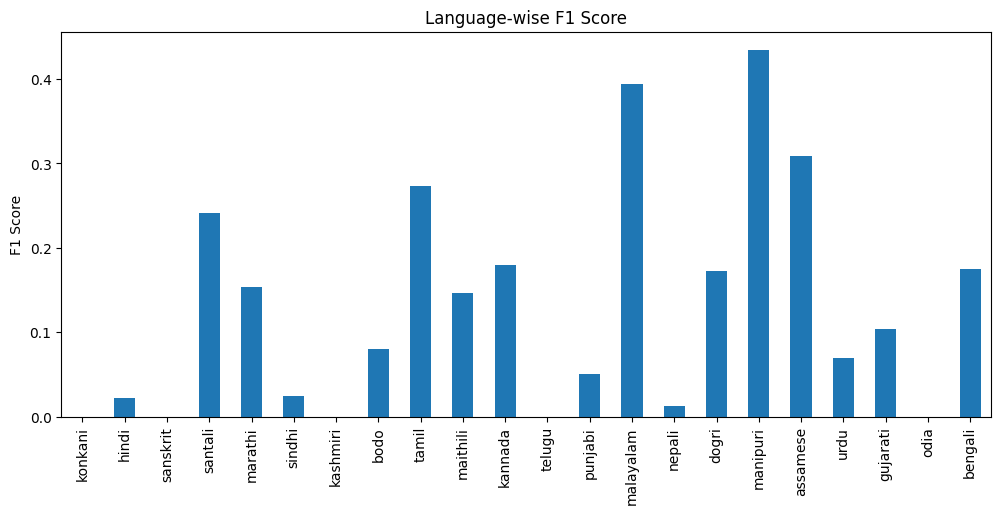

In [17]:
df_lang = df.iloc[:-3]

df_lang["f1-score"].plot(kind="bar", figsize=(12,5))

plt.title("Language-wise F1 Score")
plt.ylabel("F1 Score")
plt.show()

Training Curves (Loss and Accuracy)

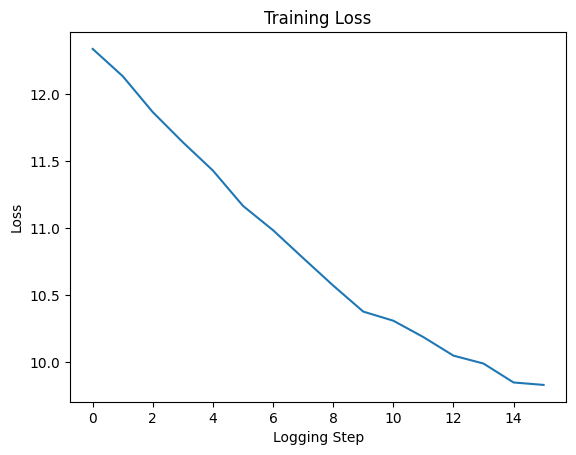

In [18]:
logs = trainer.state.log_history

train_loss = []
eval_acc = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])
    if "eval_accuracy" in log:
        eval_acc.append(log["eval_accuracy"])

plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Logging Step")
plt.ylabel("Loss")
plt.show()

Accuracy curve

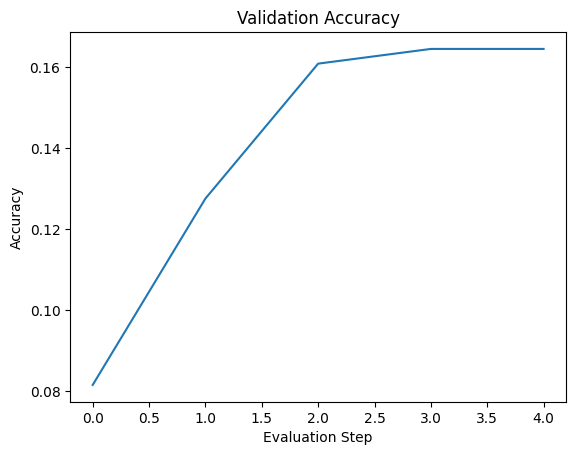

In [19]:
plt.plot(eval_acc)

plt.title("Validation Accuracy")
plt.xlabel("Evaluation Step")
plt.ylabel("Accuracy")

plt.show()

t-SNE Visualization of Embeddings

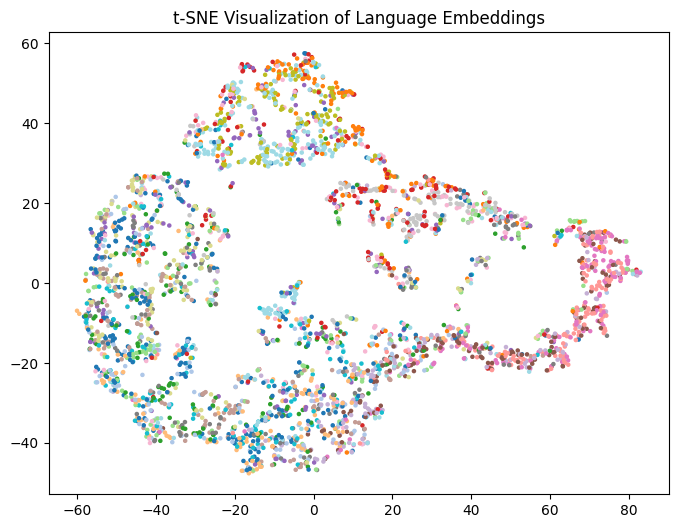

In [20]:
from sklearn.manifold import TSNE

embeddings = predictions.predictions

tsne = TSNE(n_components=2, random_state=42)

X = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X[:,0],
    X[:,1],
    c=y_true,
    cmap="tab20",
    s=5
)

plt.title("t-SNE Visualization of Language Embeddings")

plt.show()

Speaker Bias Analysis

language
assamese     5
bengali      5
bodo         5
dogri        5
gujarati     5
hindi        5
kannada      5
kashmiri     5
konkani      5
maithili     5
malayalam    5
manipuri     5
marathi      5
nepali       5
odia         5
punjabi      5
sanskrit     5
santali      5
sindhi       5
tamil        5
telugu       5
urdu         5
Name: speaker_id, dtype: int64


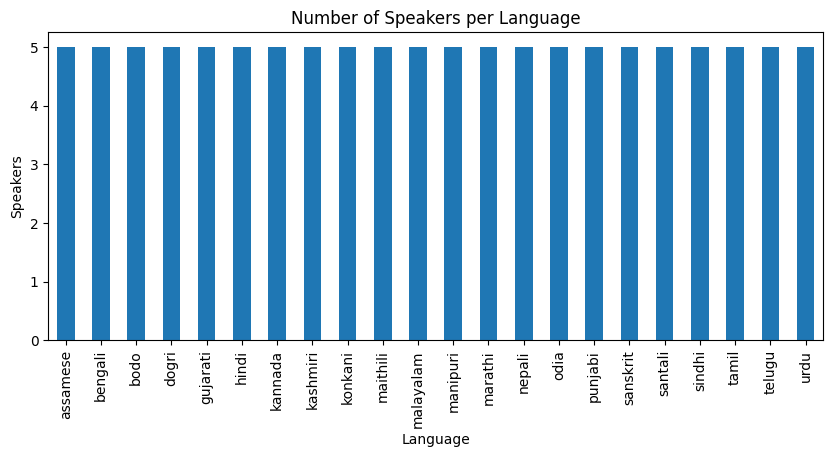

In [22]:
# Reload original dataset
dataset_raw = load_dataset("badrex/nnti-dataset-full")

train_raw = dataset_raw["train"]

speaker_counts = train_raw.to_pandas().groupby("language")["speaker_id"].nunique()

print(speaker_counts)

import matplotlib.pyplot as plt

speaker_counts.plot(kind="bar", figsize=(10,4))

plt.title("Number of Speakers per Language")
plt.ylabel("Speakers")
plt.xlabel("Language")

plt.show()

In [23]:
trainer.save_model("/kaggle/working/mms_baseline_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]